In [2]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/aiffel/seq2seq
import os
os.chdir('/content/drive/MyDrive/aiffel/seq2seq')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.2.3
2.11.0+cu128
3.10.0


In [4]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xvf korean-english-park.train.tar.gz

--2026-09-08 08:11:40--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-09-08 08:11:41--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz.9’

kore

In [5]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

# 파일 경로 지정
KO_PATH = "korean-english-park.train.ko"
EN_PATH = "korean-english-park.train.en"

# 데이터 불러오기
with open(KO_PATH, "r", encoding="utf-8") as f:
    ko_data = f.read().splitlines()

with open(EN_PATH, "r", encoding="utf-8") as f:
    en_data = f.read().splitlines()

print(f"전체 한국어 문장 수: {len(ko_data)}")
print(f"전체 영어 문장 수: {len(en_data)}")

print("\n--- 샘플 데이터 ---")
print("EN:", en_data[0])
print("KO:", ko_data[0])

2.11.0+cu128
전체 한국어 문장 수: 94123
전체 영어 문장 수: 94123

--- 샘플 데이터 ---
EN: Much of personal computing is about "can you top this?"
KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"


In [6]:
# 1. 중복 제거 (영어-한국어 쌍으로 묶어서 중복 제거)
cleaned_corpus = list(set(zip(en_data, ko_data)))
print(f"중복 제거 후 데이터 수: {len(cleaned_corpus)}")

# 2. 문장 길이 필터링 (너무 긴 문장은 학습 효율성 및 GPU 메모리 제한으로 제외)
MAX_LEN = 50  # 최대 토큰/단어 길이 제한

filtered_corpus = []
for en, ko in cleaned_corpus:
    if len(en.split()) <= MAX_LEN and len(ko.split()) <= MAX_LEN:
        filtered_corpus.append((en, ko))

print(f"길이 조건(<= {MAX_LEN}단어) 적용 후 데이터 수: {len(filtered_corpus)}")

# 데이터 분리
train_en, train_ko = map(list, zip(*filtered_corpus))

중복 제거 후 데이터 수: 78968
길이 조건(<= 50단어) 적용 후 데이터 수: 78413


In [7]:
def preprocess_sentence_korean(sentence):
    sentence = sentence.lower().strip()
    # 1. 문장 부호 앞뒤 공백 추가 (토큰화 시 단어와 구두점 분리 목적)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 2. 한글, 영어, 기본 문장부호만 남기고 잡음 제거
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)

    # 3. 연속된 공백 하나로 정리
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

In [8]:
import sentencepiece as spm

VOCAB_SIZE = 8000
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

# 1. 센텐스피스 학습용 텍스트 파일 저장 (전처리 함수 적용 필수!)
with open('train_en.txt', 'w', encoding='utf-8') as f:
    for line in train_en:
        f.write(preprocess_sentence_korean(line) + '\n')

with open('train_ko.txt', 'w', encoding='utf-8') as f:
    for line in train_ko:
        f.write(preprocess_sentence_korean(line) + '\n')

# 2. 영어 SentencePiece 모델 학습
spm.SentencePieceTrainer.train(
    input='train_en.txt',
    model_prefix='spm_en',
    vocab_size=VOCAB_SIZE,
    pad_id=PAD_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    unk_id=UNK_ID
)

# 3. 한국어 SentencePiece 모델 학습
spm.SentencePieceTrainer.train(
    input='train_ko.txt',
    model_prefix='spm_ko',
    vocab_size=VOCAB_SIZE,
    pad_id=PAD_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    unk_id=UNK_ID
)

# 4. 토크나이저 로드
sp_en = spm.SentencePieceProcessor()
sp_en.load('spm_en.model')

sp_ko = spm.SentencePieceProcessor()
sp_ko.load('spm_ko.model')

print("단어장 생성 완료!")
print("한국어 샘플 테스트:", sp_ko.encode_as_pieces(preprocess_sentence_korean("안녕하세요 나는 인성입니다.")))

단어장 생성 완료!
한국어 샘플 테스트: ['▁안', '녕', '하', '세', '요', '▁나는', '▁', '인', '성', '입니다', '▁.']


In [9]:
sample1_clean = preprocess_sentence_korean(train_ko[0])
print("원문:", sample1_clean)
print("토큰화 결과:", sp_ko.encode_as_pieces(sample1_clean))
print("인코딩 ID:", sp_ko.encode_as_ids(sample1_clean))

sample2_clean = preprocess_sentence_korean(train_en[0])
print("영어 원문:", sample2_clean)
print("토큰화 결과(Pieces):", sp_en.encode_as_pieces(sample2_clean))
print("숫자 ID 변환(IDs):", sp_en.encode_as_ids(sample2_clean))

원문: 그는 경기 참가자를 주로 vip에 속하는 선수 , 기자 , 올림픽 임원으로 나누어 이들이 만족하도록 집중 개선할 예정이다 고 말했다 .
토큰화 결과: ['▁그는', '▁경기', '▁참가', '자를', '▁주로', '▁vi', 'p', '에', '▁속', '하는', '▁선수', '▁,', '▁기자', '▁,', '▁올림픽', '▁임원', '으로', '▁나누', '어', '▁이들이', '▁만족', '하도록', '▁집중', '▁개선', '할', '▁예정이다', '▁고', '▁말했다', '▁.']
인코딩 ID: [44, 460, 1171, 1473, 3456, 4230, 316, 7, 715, 37, 573, 11, 735, 11, 602, 6210, 26, 4122, 54, 3665, 3394, 864, 1841, 1612, 32, 286, 27, 34, 5]
영어 원문: so he said the focus would be on satisfying three groups of visitors athletes , journalists and the olympic family , meaning primarily vips .
토큰화 결과(Pieces): ['▁so', '▁he', '▁said', '▁the', '▁focus', '▁would', '▁be', '▁on', '▁satisfy', 'ing', '▁three', '▁groups', '▁of', '▁visitors', '▁athletes', '▁,', '▁journalists', '▁and', '▁the', '▁olympic', '▁family', '▁,', '▁meaning', '▁primarily', '▁vi', 'p', 's', '▁.']
숫자 ID 변환(IDs): [118, 24, 14, 4, 1436, 68, 30, 16, 7889, 22, 114, 716, 10, 1732, 4279, 6, 2094, 12, 4, 1090, 337, 6, 3343, 5647, 1101, 98, 9, 5]


In [10]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("spm_en.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("spm_ko.model")

True

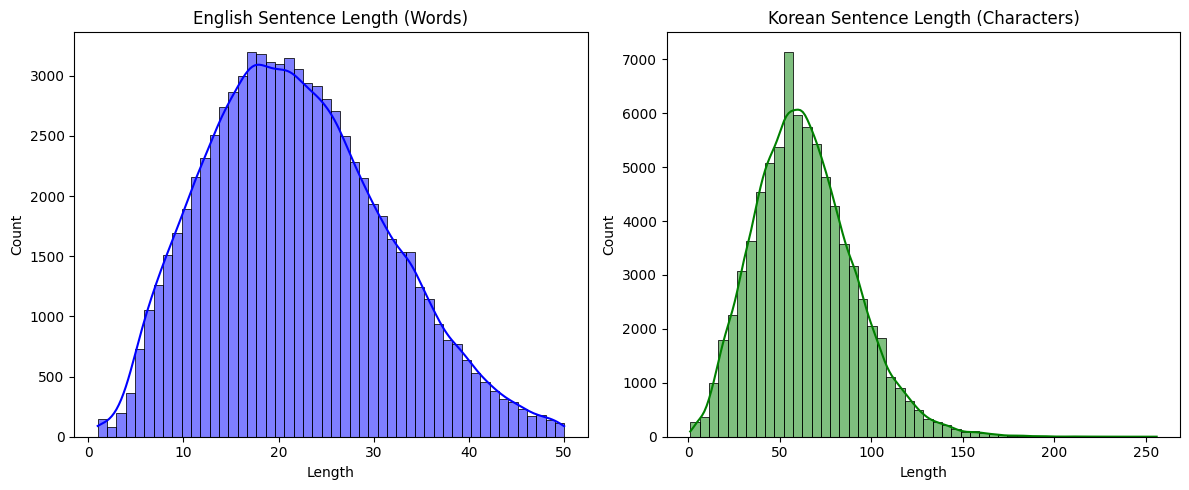

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 문장별 글자/단어 수 계산
en_lengths = [len(s.split()) for s in train_en]  # 영어 단어 수
ko_lengths = [len(s) for s in train_ko]          # 한국어 글자 수 (또는 sp_ko로 토큰화한 길이)

# 2. 그래프 그리기
plt.figure(figsize=(12, 5))

# 영어 단어 수 분포
plt.subplot(1, 2, 1)
sns.histplot(en_lengths, bins=50, kde=True, color='blue')
plt.title('English Sentence Length (Words)')
plt.xlabel('Length')
plt.ylabel('Count')

# 한국어 글자 수 분포
plt.subplot(1, 2, 2)
sns.histplot(ko_lengths, bins=50, kde=True, color='green')
plt.title('Korean Sentence Length (Characters)')
plt.xlabel('Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

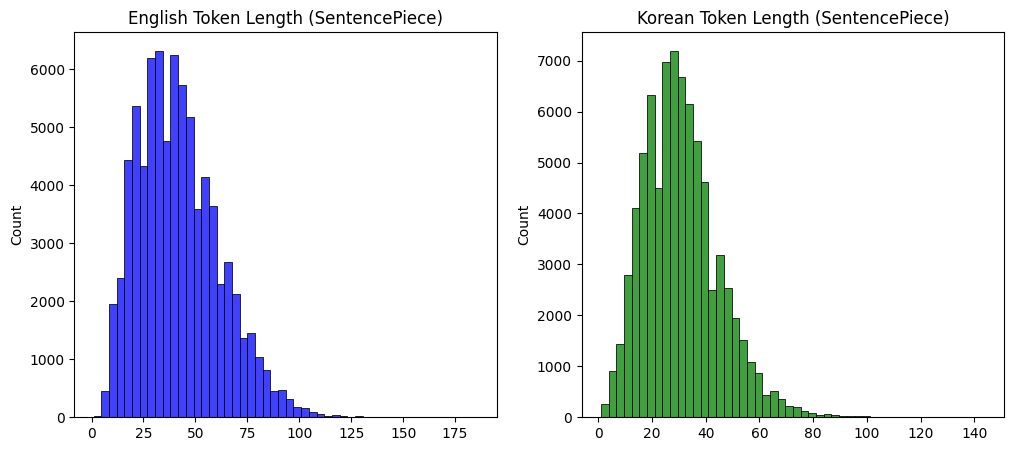

In [12]:
# SentencePiece 토크나이저 기준 토큰 개수 계산
en_token_lens = [len(sp_en.encode_as_ids(s)) for s in train_en]
ko_token_lens = [len(sp_ko.encode_as_ids(s)) for s in train_ko]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(en_token_lens, bins=50, color='blue')
plt.title('English Token Length (SentencePiece)')

plt.subplot(1, 2, 2)
sns.histplot(ko_token_lens, bins=50, color='green')
plt.title('Korean Token Length (SentencePiece)')
plt.show()

In [13]:
# 1. 빈 문장이 남아있는지 확인
empty_en = sum(1 for s in train_en if len(s.strip()) == 0)
empty_ko = sum(1 for s in train_ko if len(s.strip()) == 0)

# 2. 데이터 개수 일치 확인
print(f"영어 문장 수: {len(train_en)}, 한국어 문장 수: {len(train_ko)}")
print(f"영어 빈 문장 개수: {empty_en}, 한국어 빈 문장 개수: {empty_ko}")

# 3. 무작위 샘플 1개 출력해서 눈으로 확인
import random
idx = random.randint(0, len(train_en)-1)
print(f"\n[랜덤 샘플 {idx}번 점검]")
print("EN:", train_en[idx])
print("KO:", train_ko[idx])

영어 문장 수: 78413, 한국어 문장 수: 78413
영어 빈 문장 개수: 0, 한국어 빈 문장 개수: 0

[랜덤 샘플 14081번 점검]
EN: Clinton vowed to soldier on, telling supporters at an Indiana rally that "it's full speed on to the White House.
KO: 클린턴은 이날 경선 결과가 발표된 뒤 인디애나에서 지지자들을 향해 “백악관을 향해 전속력으로 질주하겠다”고 말했다.


In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. 기존 리스트 데이터를 8:2 비율로 분할 (원래 가지고 계신 영어/한국어 리스트 변수명)
train_en_split, val_en_split, train_ko_split, val_ko_split = train_test_split(
    train_en, train_ko, test_size=0.2, random_state=42
)

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 1. Custom Dataset 정의 (한영 번역 맞춤)
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, sp_src, sp_tgt):
        # SentencePiece 객체에서 직접 Special ID 가져오기 (기본값 대응)
        BOS_ID = sp_src.bos_id() if sp_src.bos_id() != -1 else 1
        EOS_ID = sp_src.eos_id() if sp_src.eos_id() != -1 else 2

        print("데이터셋 사전 전처리 및 인코딩 진행 중...")
        self.src_tensors = []
        self.tgt_tensors = []

        # __init__ 시점에 정규식 전처리 및 인코딩 완료
        for src_raw, tgt_raw in zip(src_sentences, tgt_sentences):
            # [핵심 수정] Source(한국어)와 Target(영어) 전처리 함수 분리 적용!
            src_clean = preprocess_sentence_korean(src_raw)
            tgt_clean = preprocess_sentence_korean(tgt_raw)  # 영어 전처리 함수 사용

            # [BOS] + encoded_ids + [EOS]
            src_ids = [BOS_ID] + sp_src.encode_as_ids(src_clean) + [EOS_ID]
            tgt_ids = [BOS_ID] + sp_tgt.encode_as_ids(tgt_clean) + [EOS_ID]

            # 텐서 변환 후 메모리 저장
            self.src_tensors.append(torch.tensor(src_ids, dtype=torch.long))
            self.tgt_tensors.append(torch.tensor(tgt_ids, dtype=torch.long))

        print(f"총 {len(self.src_tensors)}개 데이터 인코딩 완료!")

    def __len__(self):
        return len(self.src_tensors)

    def __getitem__(self, idx):
        return self.src_tensors[idx], self.tgt_tensors[idx]


# 2. collate_fn 정의 (Dynamic Padding)
def collate_fn(batch):
    # PAD ID 가져오기
    PAD_ID = sp_ko.pad_id() if sp_ko.pad_id() != -1 else 0

    src_batch = [item[0] for item in batch]
    tgt_batch = [item[1] for item in batch]

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID)
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID)

    return src_padded, tgt_padded


# 3. Dataset 및 DataLoader 생성 (한국어 -> 영어 순서로 전달!)
# [핵심 수정] (src: train_ko_split / sp_ko) -> (tgt: train_en_split / sp_en)
train_dataset = TranslationDataset(train_ko_split, train_en_split, sp_ko, sp_en)
val_dataset = TranslationDataset(val_ko_split, val_en_split, sp_ko, sp_en)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

# 첫 번째 배치 구조 및 토크나이징 정상 동작 검증
first_batch_src, first_batch_tgt = next(iter(train_loader))
print("Encoder Input (KO) Batch Shape:", first_batch_src.shape)
print("Decoder Input (EN) Batch Shape:", first_batch_tgt.shape)

print("\n")
print("KO Source Sample :", sp_ko.decode_ids(first_batch_src[0].tolist()))
print("EN Target Sample :", sp_en.decode_ids(first_batch_tgt[0].tolist()))

데이터셋 사전 전처리 및 인코딩 진행 중...
총 62730개 데이터 인코딩 완료!
데이터셋 사전 전처리 및 인코딩 진행 중...
총 15683개 데이터 인코딩 완료!
Encoder Input (KO) Batch Shape: torch.Size([128, 87])
Decoder Input (EN) Batch Shape: torch.Size([128, 63])

--- 복원 샘플 테스트 ---
KO Source Sample : ap의 스티브 그램 기자가 이슬라마바드에서 전합니다 .
EN Target Sample : the ap s steve gramm is in islamabad


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# 1. Encoder 구현
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [batch_size, src_len]
        embedded = self.dropout(self.embedding(src)) # [batch_size, src_len, emb_dim]

        # outputs: [batch_size, src_len, enc_hidden_dim * 2]
        # hidden: [2, batch_size, enc_hidden_dim] (양방향)
        outputs, hidden = self.rnn(embedded)

        # 양방향 GRU의 마지막 Hidden state 결합
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)))

        return outputs, hidden


# 2. Bahdanau Attention 구현 (PAD Masking 추가)
class Attention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hidden_dim * 2) + dec_hidden_dim, dec_hidden_dim)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask=None):
        # hidden: [batch_size, dec_hidden_dim]
        # encoder_outputs: [batch_size, src_len, enc_hidden_dim * 2]
        # mask: [batch_size, src_len] (PAD 위치는 True 또는 1)

        src_len = encoder_outputs.shape[1]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1) # [batch_size, src_len, dec_hidden_dim]

        # Energy 계산: [batch_size, src_len, dec_hidden_dim]
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))

        # Attention score: [batch_size, src_len]
        attention = self.v(energy).squeeze(2)

        # ★ PAD 토큰 마스킹 처리 (-1e9로 채워 Softmax 시 0에 수렴하게 만듦)
        if mask is not None:
            attention = attention.masked_fill(mask == 0, -1e10)

        return F.softmax(attention, dim=1)


# 3. Decoder 구현
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, attention, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hidden_dim * 2) + emb_dim, dec_hidden_dim, batch_first=True)
        self.fc_out = nn.Linear((enc_hidden_dim * 2) + dec_hidden_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs, mask=None):
        # input: [batch_size]
        input = input.unsqueeze(1) # [batch_size, 1]
        embedded = self.dropout(self.embedding(input)) # [batch_size, 1, emb_dim]

        # Mask를 Attention에 전달
        a = self.attention(hidden, encoder_outputs, mask) # [batch_size, src_len]
        a = a.unsqueeze(1) # [batch_size, 1, src_len]

        weighted = torch.bmm(a, encoder_outputs) # [batch_size, 1, enc_hidden_dim * 2]

        rnn_input = torch.cat((embedded, weighted), dim=2)

        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))

        embedded = embedded.squeeze(1)
        output = output.squeeze(1)
        weighted = weighted.squeeze(1)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))

        return prediction, hidden.squeeze(0)


# 4. Seq2Seq 메인 모듈 구현
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.device = device

    def create_mask(self, src):
        # PAD_ID(0)가 아닌 위치만 1(True)로 설정
        mask = (src != self.pad_idx)
        return mask

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src: [batch_size, src_len]
        # tgt: [batch_size, tgt_len]

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # Encoder 통과 및 Mask 생성
        encoder_outputs, hidden = self.encoder(src)
        mask = self.create_mask(src)

        # Decoder의 첫 입력: <BOS> 토큰
        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden, encoder_outputs, mask)

            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input = tgt[:, t] if teacher_force else top1

        return outputs

In [19]:
# 5. 하이퍼파라미터 및 모델 객체 정의
INPUT_DIM = sp_ko.vocab_size()   #  Encoder: 한국어 단어장 크기
OUTPUT_DIM = sp_en.vocab_size()  #  Decoder: 영어 단어장 크기

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
DROPOUT = 0.2

# [수정] 한국어 토크나이저 기준 PAD_ID 추출
PAD_ID = sp_ko.pad_id() if sp_ko.pad_id() != -1 else 0

# Attention, Encoder, Decoder 객체 생성
attn = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, dropout=DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attn, dropout=DROPOUT)

# 최종 Seq2Seq 메인 모델에 PAD_ID를 전달하여 생성 후 device로 이동
model = Seq2Seq(enc, dec, PAD_ID, device).to(device)

print(f"인코더(KO) Vocab Size: {INPUT_DIM}")
print(f"디코더(EN) Vocab Size: {OUTPUT_DIM}")
print("모델 정의 및 디바이스 이동 완료!")
print(device)

인코더(KO) Vocab Size: 8000
디코더(EN) Vocab Size: 8000
모델 정의 및 디바이스 이동 완료!
cuda


In [20]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

In [21]:
def train_step(model, data_loader, optimizer, criterion, epoch, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, tgt in progress_bar:
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        # 1. teacher_forcing_ratio를 명시적으로 전달
        outputs = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)

        output_dim = outputs.shape[-1]

        # 2. outputs와 tgt의 타임스텝 길이를 일치시켜 flattening
        # outputs: [batch_size, tgt_len - 1, vocab_size]
        # tgt_label: [batch_size, tgt_len - 1]
        outputs = outputs[:, 1:].reshape(-1, output_dim)
        tgt_label = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, tgt_label)
        loss.backward()

        # Gradient Clipping (1.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


def eval_step(model, data_loader, criterion, epoch):
    model.eval()
    total_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Test Epoch {epoch+1}", leave=True)

    with torch.no_grad():
        for src, tgt in progress_bar:
            src = src.to(device)
            tgt = tgt.to(device)

            # 평가 시에는 Teacher Forcing 완전 OFF (0.0)
            outputs = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = outputs.shape[-1]
            outputs = outputs[:, 1:].reshape(-1, output_dim)
            trg_label = tgt[:, 1:].reshape(-1)

            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

            progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(data_loader)

In [24]:
%%time

EPOCHS = 7

# 손실 기록용 리스트
train_losses = []
valid_losses = []

# ★ 가장 낮은 검증 손실을 저장할 변수 (초기값은 무한대)
best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    # 1. Train 실행
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)

    # 2. Validation 실행
    valid_loss = eval_step(model, validation_loader, criterion, epoch)

    # 손실값 기록
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # ★ 핵심: 검증 손실이 기존 최저값보다 낮으면 가중치 저장
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f" -> Best Model 저장 완료! (Valid Loss: {valid_loss:.4f})")

    print(f" Epoch {epoch+1:02d}/{EPOCHS:02d} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

# ★ 학습 종료 후 가장 성능이 좋았던 모델 가중치 불러오기
model.load_state_dict(torch.load('best_model.pt'))
print("\n최고 성능 모델 가중치 로드 완료!")

Test Epoch 1: 100%|██████████| 123/123 [00:47<00:00,  2.57it/s, loss=6.35]


 -> Best Model 저장 완료! (Valid Loss: 6.3543)
 Epoch 01/07 | Train Loss: 6.1328 | Valid Loss: 6.3543


Test Epoch 2: 100%|██████████| 123/123 [00:47<00:00,  2.59it/s, loss=6.2]


 -> Best Model 저장 완료! (Valid Loss: 6.1962)
 Epoch 02/07 | Train Loss: 5.4751 | Valid Loss: 6.1962


Test Epoch 3: 100%|██████████| 123/123 [00:47<00:00,  2.59it/s, loss=6.16]


...

 Epoch 05/07 | Train Loss: 4.5962 | Valid Loss: 6.2069


Test Epoch 6: 100%|██████████| 123/123 [00:47<00:00,  2.58it/s, loss=6.34]


 Epoch 06/07 | Train Loss: 4.4346 | Valid Loss: 6.2768


Test Epoch 7: 100%|██████████| 123/123 [00:47<00:00,  2.57it/s, loss=6.44]

 Epoch 07/07 | Train Loss: 4.2870 | Valid Loss: 6.3441

최고 성능 모델 가중치 로드 완료!
CPU times: user 39min 49s, sys: 19min 1s, total: 58min 50s
Wall time: 58min 52s


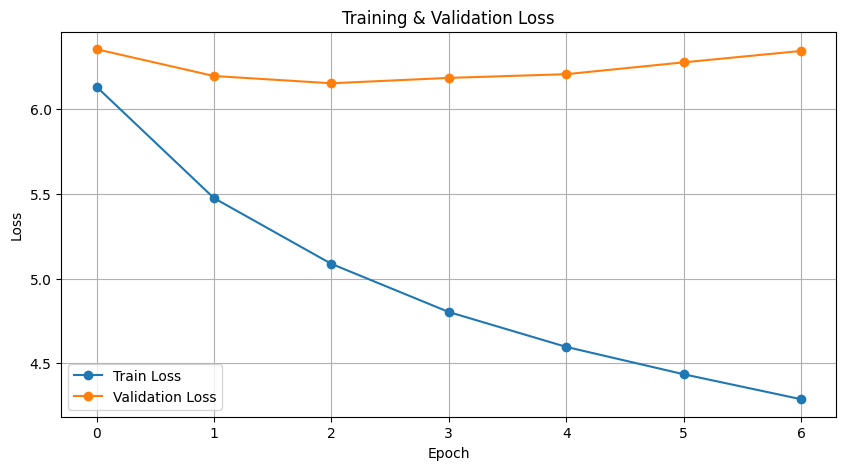

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(valid_losses, label='Validation Loss', marker='o')

plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
import torch

def translate_sentence(sentence, model, sp_src, sp_tgt, device, max_len=50, repetition_penalty=1.5):
    model.eval()

    # 소스(영어)와 타겟(한국어) 특수 토큰 ID 분리
    src_bos_id = sp_src.bos_id() if sp_src.bos_id() != -1 else 1
    src_eos_id = sp_src.eos_id() if sp_src.eos_id() != -1 else 2
    tgt_bos_id = sp_tgt.bos_id() if sp_tgt.bos_id() != -1 else 1
    tgt_eos_id = sp_tgt.eos_id() if sp_tgt.eos_id() != -1 else 2

    # 1. 원문 전처리 및 토크나이즈
    clean_text = preprocess_sentence_korean(sentence)
    src_ids = sp_src.encode_as_ids(clean_text)

    src_tensor = torch.tensor([src_bos_id] + src_ids + [src_eos_id], dtype=torch.long).unsqueeze(0).to(device)

    # 2. Encoder 통과 및 Attention Mask 생성
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        mask = model.create_mask(src_tensor)

    # 디코더의 첫 입력은 타겟(한국어)의 <BOS> 토큰
    trg_indexes = [tgt_bos_id]

    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).to(device)

        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden, encoder_outputs, mask)

        # 반복 패널티 적용 (Logit 차감 방식)
        for token_id in set(trg_indexes):
            if token_id not in [tgt_bos_id, tgt_eos_id]:
                output[0, token_id] = -1e9

        pred_token = output.argmax(1).item()

        # 타겟의 EOS 토큰 감지 시 즉시 종료
        if pred_token == tgt_eos_id:
            break

        trg_indexes.append(pred_token)

    # BOS 제외 디코딩
    translated_ids = [idx for idx in trg_indexes if idx != tgt_bos_id]
    translated_text = sp_tgt.decode_ids(translated_ids)
    return translated_text

print("수정된 translate_sentence 정의 완료!")

수정된 translate_sentence 정의 완료!


```python
        for token_id in set(trg_indexes):
            if token_id not in [tgt_bos_id, tgt_eos_id]:
                output[0, token_id] = -1e9
```

-1e9를 줬을 때 그나마 가장 깔끔하게 번역을 해줬습니다.  
-1e9가 아닌 다른 값으로 테스트를 했을때 coffee coffee coffee 등 반복적인 단어가 나오는 문제가 있었습니다.

In [36]:
test_ko_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for i, ko_sent in enumerate(test_ko_sentences, 1):
    en_translation = translate_sentence(ko_sent, model, sp_ko, sp_en, device)
    print(f"K{i}) {ko_sent}")
    print(f"E{i}) {en_translation}\n")

K1) 오바마는 대통령이다.
E1) obama is a president .

K2) 시민들은 도시 속에 산다.
E2) the are town cities urban .

K3) 커피는 필요 없다.
E3) coffees the world .

K4) 일곱 명의 사망자가 발생했다.
E4) at least people were injured , .



번역이 너무 이상해보여서 코드를 삭제하며 다시 실행하여 학습시키고 반복 해봤지만 크게 나아지는 모습은 발견하지 못했습니다.  
결과를 조금이라도 바꿔보고 싶어 계속 코드를 추가 수정하다보니 output[0, token_id] 의 값의 변화에 번역이 달라지는 결과도 확인 했습니다.  
특정 단어에 지나치게 의존하는 현상이 나온거 같습니다.  
어텐션은 기억 소실을 방지하기 위해 나오긴 했지만 완벽하게 기억 소실을 방지하지는 못하는 것으로 알고 있습니다.  
그래서 이걸 해결하기 위해 나온게 이제 앞으로 배울 트랜스포머이며  
llm의 근간을 이루는 핵심이라고 알고 있어서 배워서 활용 해보고 싶습니다.